## AMR Modelling pipeline

#### Libarary imports

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score, average_precision_score)
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap

#### Load Data already preprocessed

In [6]:
df = pd.read_csv('../Data/processed/amr_final_v2.csv')

#### Build 4 drug-class targets

In [7]:
DRUG_CLASSES = {
    'target_beta_lactam'   : ['amoxicillin_ampicillin','amoxicillin_clavulanate',
                               'cefazolin','cefoxitin','cefotaxime_ceftriaxone','imipenem'],
    'target_aminoglycoside': ['gentamicin','amikacin'],
    'target_quinolone'     : ['nalidixic_acid','ofloxacin','ciprofloxacin'],
    'target_other'         : ['chloramphenicol','cotrimoxazole','nitrofurantoin','colistin'],
}

for target, ab_cols in DRUG_CLASSES.items():
    present = [c for c in ab_cols if c in df.columns]
    vals = df[present].replace(-1, np.nan)
    # majority vote: R if any resistant, else I if any intermediate, else S
    df[target] = np.where(vals.eq(2).any(axis=1), 2,
                 np.where(vals.eq(1).any(axis=1), 1, 0))
    df[target] = df[target].where(vals.notna().any(axis=1), np.nan)

TARGET_COLS = list(DRUG_CLASSES.keys())

print("Target distributions:")
for t in TARGET_COLS:
    print(f"  {t}: {df[t].value_counts(dropna=False).to_dict()}")

# ── Define CLEAN feature set
# Remove: raw AB cols (these are targets), engineered features
# derived FROM those AB cols (n_resistant_*, pct_*, phenotype_*,
# total_*, overall_*, is_mdr, is_critical_mdr etc.)

RAW_AB_COLS = ['amoxicillin_ampicillin','amoxicillin_clavulanate','cefazolin',
               'cefoxitin','cefotaxime_ceftriaxone','imipenem','gentamicin',
               'amikacin','nalidixic_acid','ofloxacin','ciprofloxacin',
               'chloramphenicol','cotrimoxazole','nitrofurantoin','colistin']

LEAKY_PREFIXES = ['n_resistant','n_tested','pct_resistant','total_resistant',
                  'total_antibiotics','overall_resistance','is_mdr',
                  'is_critical','phenotype_','quinolone_cross','dual_carb',
                  'n_classes_resistant']

CLEAN_FEATURES = [
    c for c in df.columns
    if c not in RAW_AB_COLS
    and c not in TARGET_COLS
    and c not in ['bacteria_strain', 'source', 'gender']
    and not any(c.startswith(p) for p in LEAKY_PREFIXES)
    # Drop near-zero variance CARD binaries
    and c not in ['card_has_inactivation','card_has_efflux',
                  'card_has_target_alteration','metadata_imputed']
]

print(f"\nClean features ({len(CLEAN_FEATURES)}):")
print(CLEAN_FEATURES)

Target distributions:
  target_beta_lactam: {2: 9688, 0: 455, 1: 88}
  target_aminoglycoside: {0: 6510, 2: 3490, 1: 231}
  target_quinolone: {0: 6323, 2: 3690, 1: 218}
  target_other: {0.0: 5652, 2.0: 4200, nan: 274, 1.0: 105}

Clean features (25):
['species_enc', 'age', 'gender_enc', 'has_diabetes', 'has_hypertension', 'prior_hospitalisation', 'is_mendeley', 'card_n_active_drug_classes', 'card_relevant_gene_count', 'card_mechanism_diversity', 'card_gene_family_diversity', 'card_has_target_protection', 'card_has_reduced_permeability', 'card_has_ctx_m', 'card_has_tem', 'card_has_kpc', 'card_has_ndm', 'card_has_vim', 'card_has_imp', 'card_has_oxa_48', 'card_has_mcr', 'card_has_qnr', 'card_has_aac', 'card_has_rnd_efflux', 'card_has_mfs_efflux']


#### Per-target modelling


TARGET: target_beta_lactam
Class distribution: {2: 9688, 0: 455, 1: 88}
After SMOTE: {2: 7750, 0: 7750, 1: 7750}

Results:
  Weighted F1 : 0.995   ← headline metric
  Macro F1    : 0.881   ← penalises minority class
  Accuracy    : 0.995
  ROC-AUC     : 1.000

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.94      0.93      0.94        91
Intermediate       0.68      0.72      0.70        18
   Resistant       1.00      1.00      1.00      1938

    accuracy                           0.99      2047
   macro avg       0.88      0.89      0.88      2047
weighted avg       0.99      0.99      0.99      2047



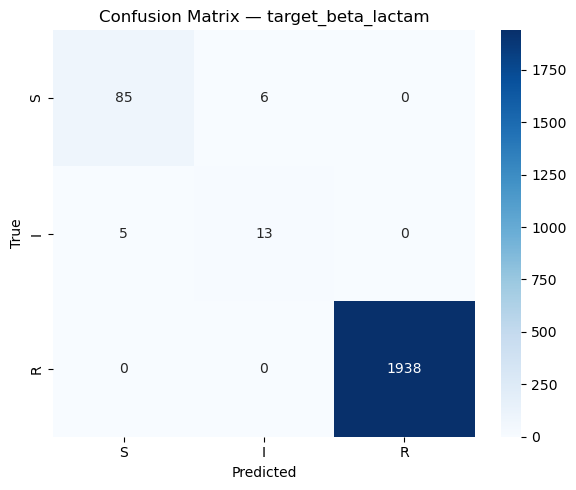

/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packa

  5-Fold CV weighted F1: 0.994 ± 0.002

TARGET: target_aminoglycoside
Class distribution: {0: 6510, 2: 3490, 1: 231}
After SMOTE: {0: 5207, 2: 5207, 1: 5207}

Results:
  Weighted F1 : 0.961   ← headline metric
  Macro F1    : 0.742   ← penalises minority class
  Accuracy    : 0.957
  ROC-AUC     : 0.990

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.98      0.96      0.97      1303
Intermediate       0.22      0.33      0.26        46
   Resistant       1.00      1.00      1.00       698

    accuracy                           0.96      2047
   macro avg       0.73      0.76      0.74      2047
weighted avg       0.97      0.96      0.96      2047



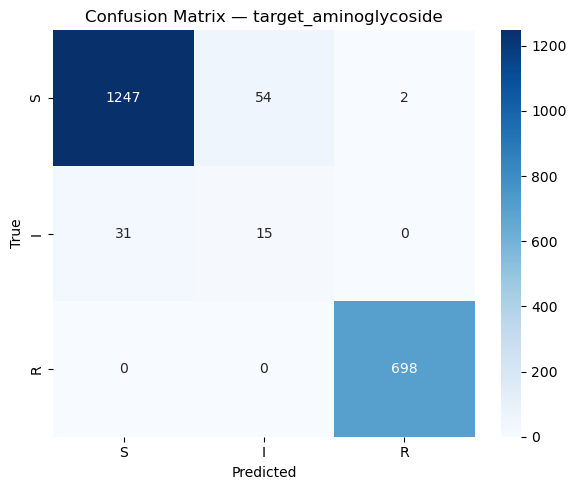

/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packa

  5-Fold CV weighted F1: 0.966 ± 0.011

TARGET: target_quinolone
Class distribution: {0: 6323, 2: 3690, 1: 218}
After SMOTE: {2: 5058, 0: 5058, 1: 5058}

Results:
  Weighted F1 : 0.966   ← headline metric
  Macro F1    : 0.754   ← penalises minority class
  Accuracy    : 0.962
  ROC-AUC     : 0.992

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.98      0.96      0.97      1265
Intermediate       0.25      0.36      0.29        44
   Resistant       1.00      1.00      1.00       738

    accuracy                           0.96      2047
   macro avg       0.74      0.77      0.75      2047
weighted avg       0.97      0.96      0.97      2047



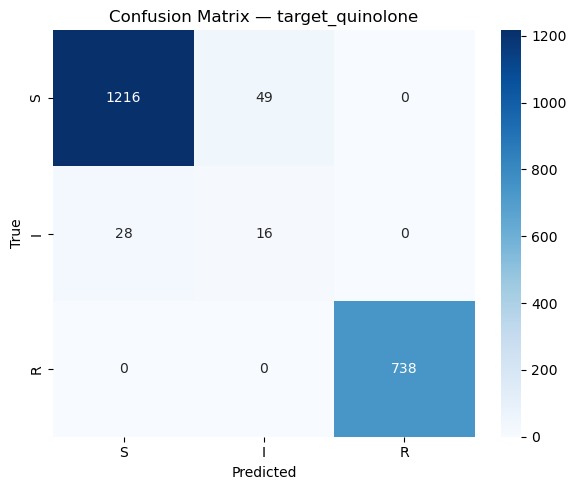

/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packa

  5-Fold CV weighted F1: 0.973 ± 0.006

TARGET: target_other
Class distribution: {0: 5652, 2: 4200, 1: 105}
After SMOTE: {0: 4521, 2: 4521, 1: 4521}

Results:
  Weighted F1 : 0.980   ← headline metric
  Macro F1    : 0.753   ← penalises minority class
  Accuracy    : 0.979
  ROC-AUC     : 0.997

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.98      0.98      0.98      1131
Intermediate       0.24      0.33      0.28        21
   Resistant       1.00      0.99      1.00       840

    accuracy                           0.98      1992
   macro avg       0.74      0.77      0.75      1992
weighted avg       0.98      0.98      0.98      1992



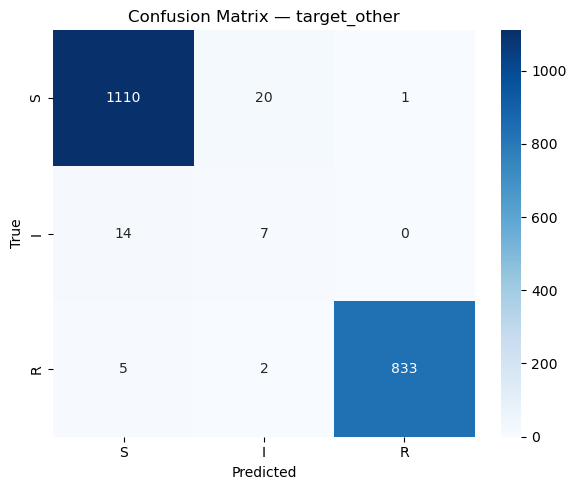

/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:30:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packa

  5-Fold CV weighted F1: 0.988 ± 0.003


In [9]:
CLASS_NAMES = {0: 'Susceptible', 1: 'Intermediate', 2: 'Resistant'}
results = {}
trained_models = {}
shap_values_dict = {}

for target in TARGET_COLS:
    print(f"\n{'='*60}")
    print(f"TARGET: {target}")
    print('='*60)

    # Drop rows where target is NaN
    data = df[df[target].notna()].copy()
    X = data[CLEAN_FEATURES].fillna(0)
    y = data[target].astype(int)

    print(f"Class distribution: {y.value_counts().to_dict()}")

    # Train/test split — stratified on target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # SMOTE for multiclass imbalance
    # k_neighbors must be < smallest class count
    min_class_count = y_train.value_counts().min()
    k = min(5, min_class_count - 1)
    if k >= 1:
        sm = SMOTE(random_state=42, k_neighbors=k)
        X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
    else:
        X_train_sm, y_train_sm = X_train, y_train

    print(f"After SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")

    # Compute class weights for XGBoost sample_weight
    from sklearn.utils.class_weight import compute_sample_weight
    sample_weights = compute_sample_weight('balanced', y_train_sm)

    # XGBoost multiclass
    model = XGBClassifier(
        objective='multi:softmax',
        num_class=3,
        n_estimators=400,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        use_label_encoder=False,
    )
    model.fit(X_train_sm, y_train_sm, sample_weight=sample_weights)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    # Metrics
    wf1  = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mf1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    acc  = (y_test.values == y_pred).mean()

    # ROC-AUC (one-vs-rest for multiclass)
    classes_present = sorted(y_test.unique())
    if len(classes_present) == 3:
        y_bin = label_binarize(y_test, classes=[0, 1, 2])
        auc   = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='weighted')
    else:
        auc = np.nan

    results[target] = {
        'weighted_f1': wf1, 'macro_f1': mf1,
        'accuracy': acc, 'roc_auc': auc , 
    }
    trained_models[target] = model

    print(f"\nResults:")
    print(f"  Weighted F1 : {wf1:.3f}   ← headline metric")
    print(f"  Macro F1    : {mf1:.3f}   ← penalises minority class")
    print(f"  Accuracy    : {acc:.3f}")
    print(f"  ROC-AUC     : {auc:.3f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['Susceptible','Intermediate','Resistant'],
          zero_division=0))

    # Confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['S','I','R'], yticklabels=['S','I','R'])
    ax.set_title(f'Confusion Matrix — {target}')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'../outputs/cm_{target}.png', dpi=120)
    plt.show()

    # 5-fold CV for stability
    cv_scores = cross_val_score(
        XGBClassifier(objective='multi:softmax', num_class=3,
                      n_estimators=200, random_state=42, use_label_encoder=False,
                      eval_metric='mlogloss', n_jobs=-1),
        X, y, cv=5, scoring='f1_weighted', n_jobs=-1
    )
    print(f"  5-Fold CV weighted F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    results[target]['cv_mean'] = cv_scores.mean()
    results[target]['cv_std']  = cv_scores.std()

#### Summary table

In [10]:
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
summary = pd.DataFrame(results).T
print(summary.round(3).to_string())


FINAL RESULTS SUMMARY
                       weighted_f1  macro_f1  accuracy  roc_auc  cv_mean  cv_std
target_beta_lactam           0.995     0.881     0.995    1.000    0.994   0.002
target_aminoglycoside        0.961     0.742     0.957    0.990    0.966   0.011
target_quinolone             0.966     0.754     0.962    0.992    0.973   0.006
target_other                 0.980     0.753     0.979    0.997    0.988   0.003


#### SHAP ANALYSIS FOR FEATURE IMPORTANCE


[SHAP] Computing feature importance (Interventional Fallback)...

── Processing Target: target_beta_lactam ──


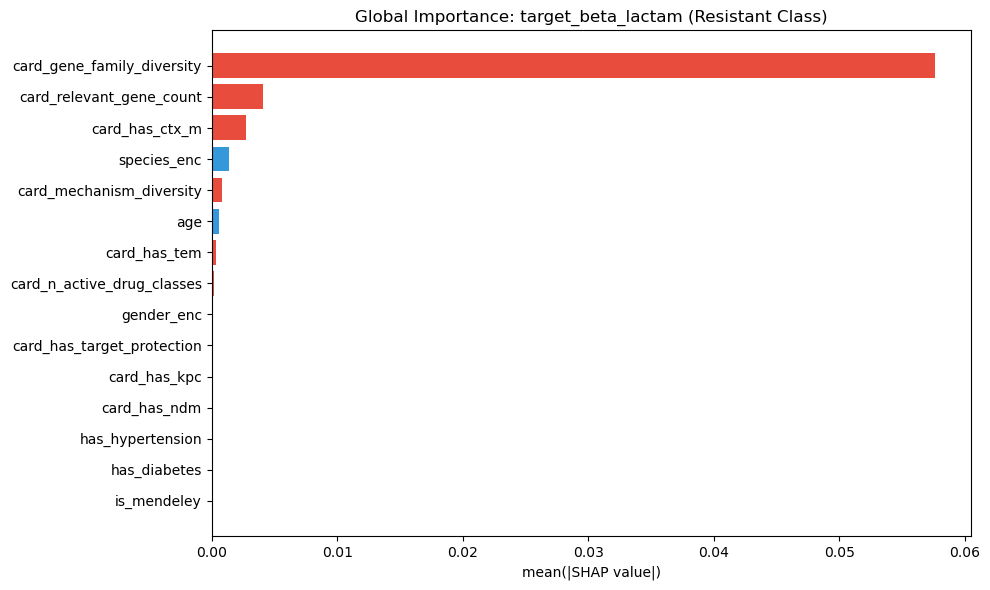

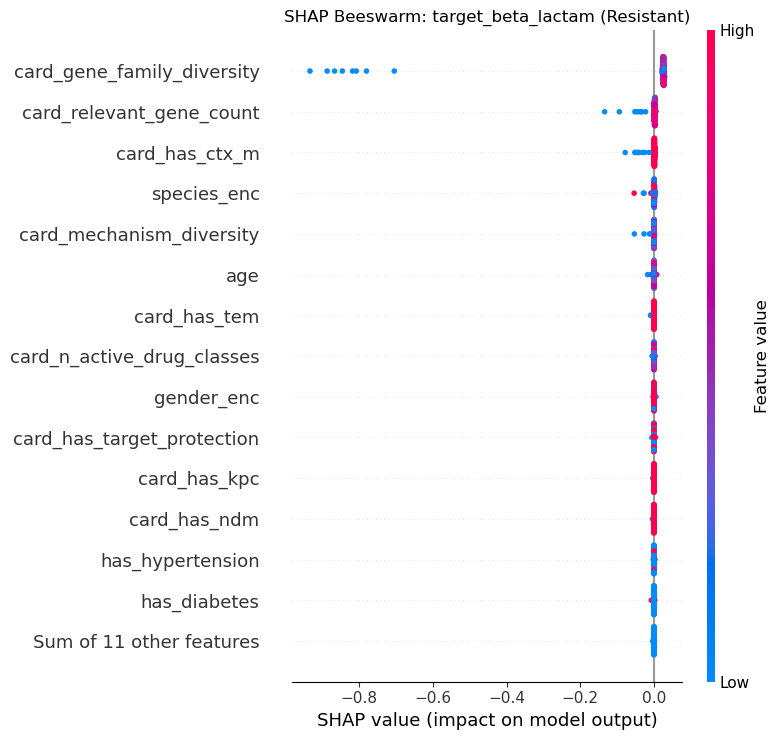


── Processing Target: target_aminoglycoside ──


PermutationExplainer explainer: 201it [00:10,  1.30s/it]                         


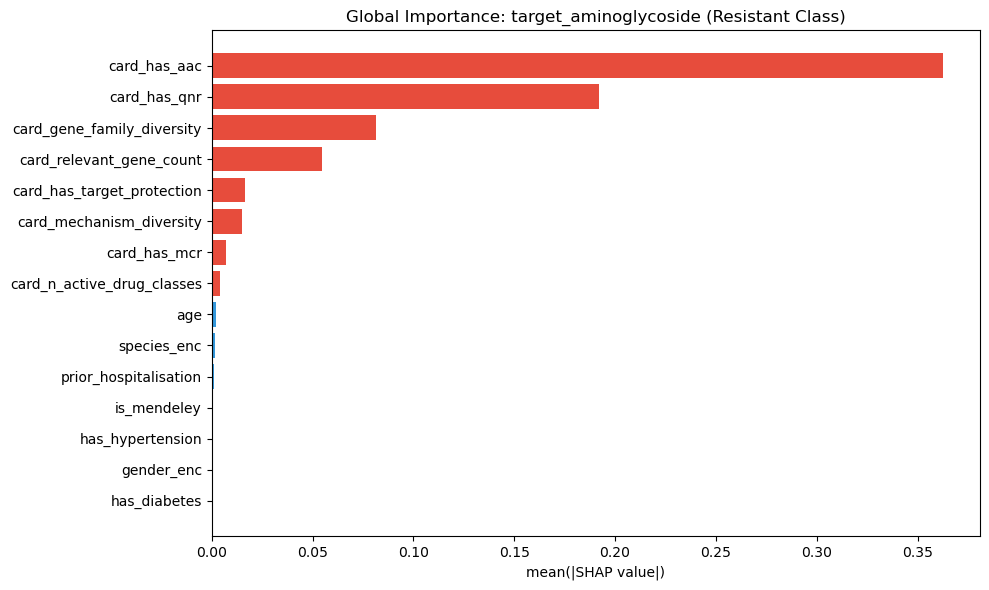

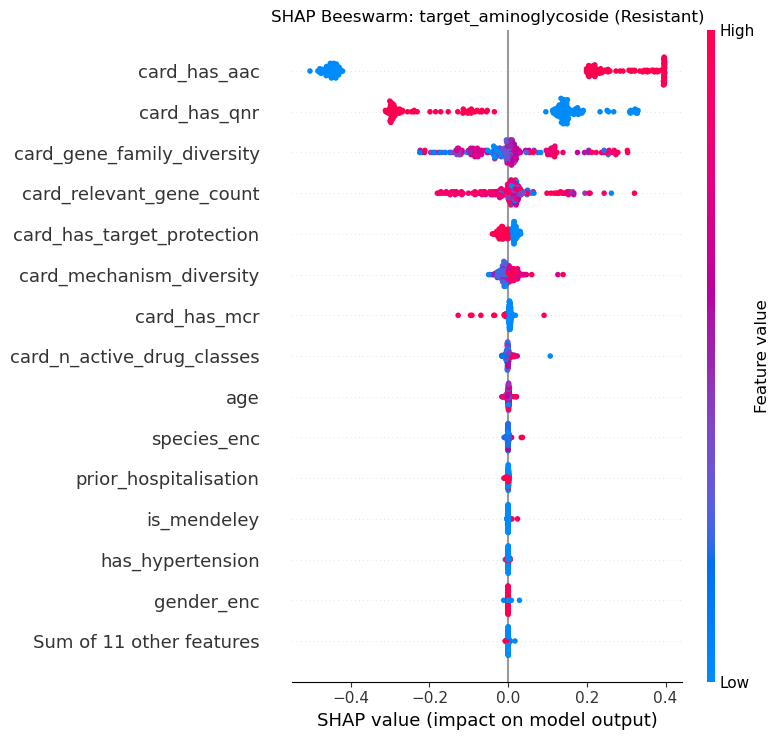


── Processing Target: target_quinolone ──


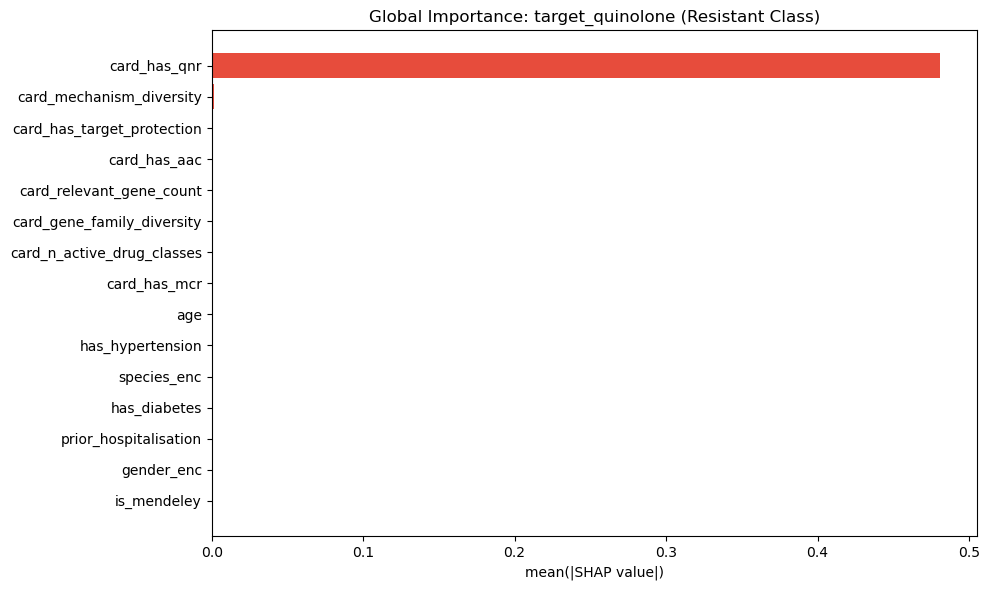

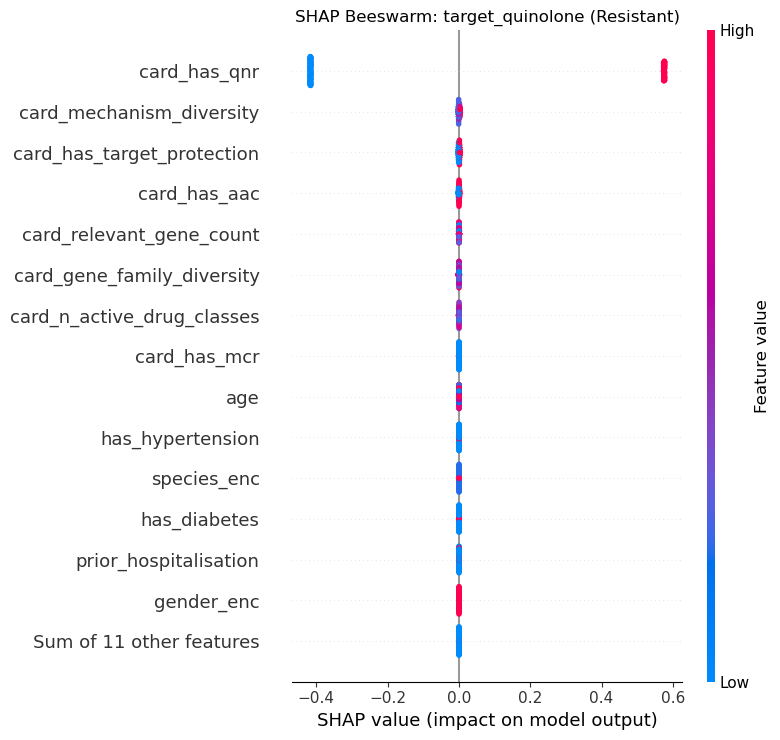


── Processing Target: target_other ──


PermutationExplainer explainer: 201it [00:13,  3.71it/s]                         


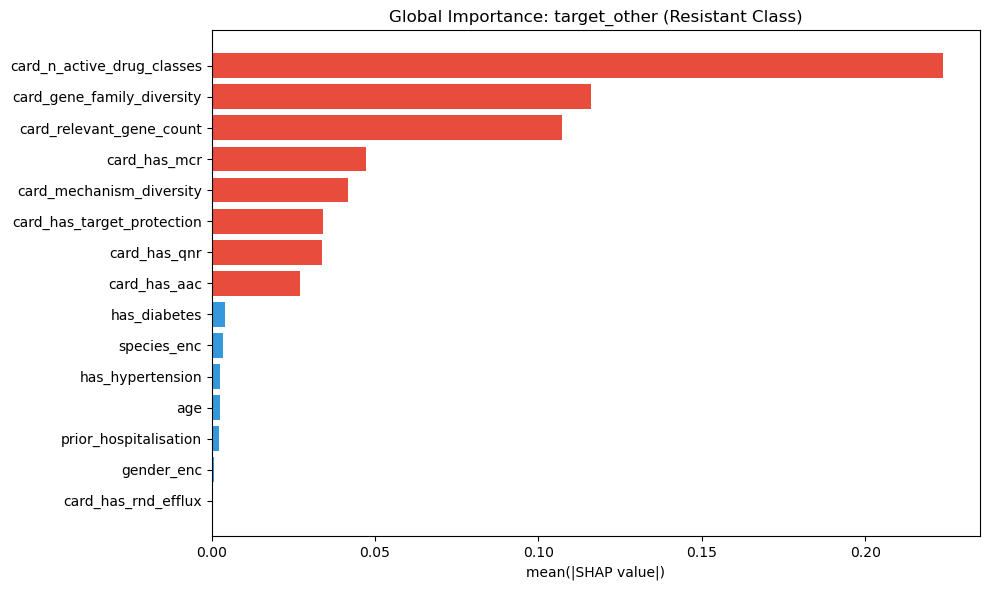

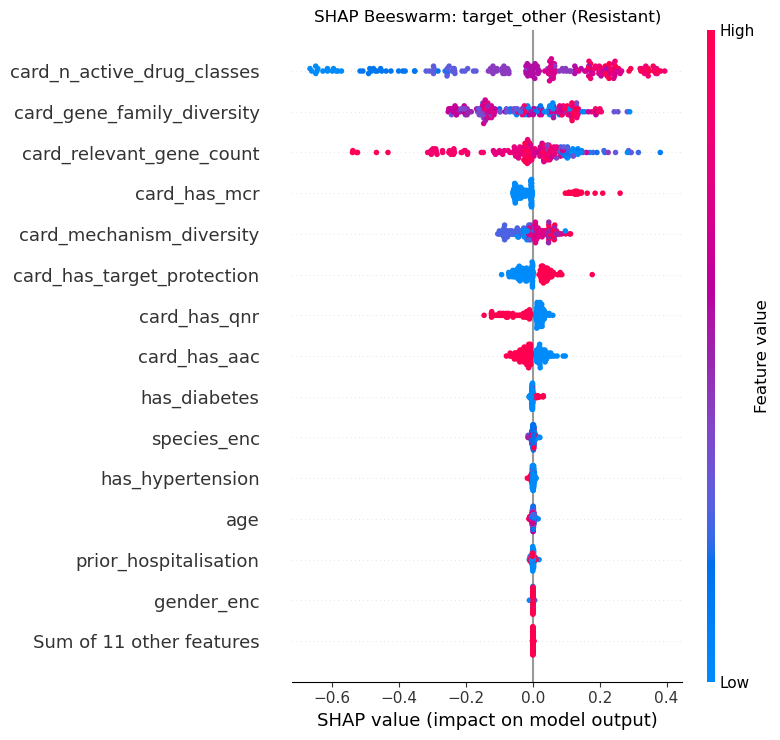


All plots saved successfully using Interventional SHAP.


In [12]:
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

os.makedirs('../outputs', exist_ok=True)
print("\n[SHAP] Computing feature importance (Interventional Fallback)...")

for target in TARGET_COLS:
    print(f"\n── Processing Target: {target} ──")
    
    model = trained_models[target]
    data = df[df[target].notna()].copy()
    

    X_background = data[CLEAN_FEATURES].fillna(0).sample(min(100, len(data)), random_state=42)
    X_test = data[CLEAN_FEATURES].fillna(0).sample(min(200, len(data)), random_state=42)

   
    explainer = shap.Explainer(model.predict_proba, X_background)
    shap_values = explainer(X_test)
    # ─────────────────────────────────────────────────────────

    # In multiclass, shap_values.values is (samples, features, classes)
    # Target Class 2 = Resistant
    if len(shap_values.values.shape) == 3:
        sv_resistant_values = shap_values.values[:, :, 2]
        base_val = shap_values.base_values[0, 2] if hasattr(shap_values.base_values, "shape") else shap_values.base_values[2]
    else:
        # Binary case fallback
        sv_resistant_values = shap_values.values
        base_val = shap_values.base_values

    # ── Global Importance (Bar Chart) ────────────────────────
    mean_abs_shap = np.abs(sv_resistant_values).mean(axis=0)
    importance_df = pd.Series(mean_abs_shap, index=CLEAN_FEATURES).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    top_15 = importance_df.head(15)
    colors = ['#e74c3c' if 'card' in f.lower() else '#3498db' for f in top_15.index]
    
    plt.barh(range(len(top_15)), top_15.values[::-1], color=colors[::-1])
    plt.yticks(range(len(top_15)), top_15.index[::-1])
    plt.title(f'Global Importance: {target} (Resistant Class)')
    plt.xlabel('mean(|SHAP value|)')
    plt.tight_layout()
    plt.savefig(f'../outputs/shap_bar_{target}.png')
    plt.show()

    # ── Local Impact (Beeswarm) ─────────────────────────────
    # Create the Explanation object for the specific class
    exp_obj = shap.Explanation(
        values=sv_resistant_values,
        base_values=base_val,
        data=X_test.values,
        feature_names=CLEAN_FEATURES
    )

    plt.figure(figsize=(10, 8))
    shap.plots.beeswarm(exp_obj, max_display=15, show=False)
    plt.title(f'SHAP Beeswarm: {target} (Resistant)')
    plt.tight_layout()
    plt.savefig(f'../outputs/shap_beeswarm_{target}.png')
    plt.show()

print("\nAll plots saved successfully using Interventional SHAP.")

In [ ]:
for target, model in trained_models.items():
    fname = f'../models/xgb_{target.replace("target_", "")}.pkl'
    with open(fname, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved: {fname}")

print("\nAll models saved to ../models/")

Saved: ../models/xgb_beta_lactam.pkl
Saved: ../models/xgb_aminoglycoside.pkl
Saved: ../models/xgb_quinolone.pkl
Saved: ../models/xgb_other.pkl

All models saved to ../models/


Exception ignored in: <function ResourceTracker.__del__ at 0x104f52020>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104476020>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103bd2020>
Traceback (most recent call last